# General pipeline

#### General pre-processing, cleaning and model training steps relevant for all data versions.
#### It's aim is to experiment with different combinations of features to determine predictive value of features added for enrichment.
#### The pipeline is based on TM-RugPull initial analysis and includes only steps that are relevant and were proven to be useful for the dataset.

In [1]:
 # Loading data from .xlsx file
 # 'data/TM-RugPull_prepared_for_enrichment.xlsx' - baseline (original dataset after cleaning and pre-processing)

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot

def load_data(filename):
    data = pd.read_excel(filename)
    # Remove a space in the end of some column names
    data.columns = data.columns.str.strip()
    return data

data = load_data('data/TM-RugPull_prepared_for_enrichment.xlsx')

data.head(5)

,Project Title,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,...,class,project starting date,project end date,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2),Contract address
0,HyperVerse Token (HVT),7.650000e+00,1.500000e-01,9.100000e-06,8.000000e-07,BSC,623909,25752,0.009537,4.929203e-02,...,scam,2022-01-27,2023-07-14,148,148,29,8,74,47,0xaafa10755b3b1dbf46e86d973c3f27f3671ed9db
1,Fintoch,1.795000e-11,1.907000e-11,1.727000e-10,1.769000e-10,BSC,"1,492,842","147,791",2487.228167,4.503032e+07,...,scam,2022-07-12,2023-06-19,820,167,4530,1590,48,4,0x19a00e359990ec7daf6e9dd9a2fb7664014bb5f7
2,Flare Token,1.955000e-03,5.519000e-04,4.158000e-04,2.838000e-04,BSC,"184,694",15173,890171363872314.625,6.695544e+17,...,scam,2021-10-24,2022-11-24,421,156,6,5,1710,1150,0x85aa3f04e539e426cbb55c0d584ea99cfe1d96a1
3,Safuu Protocol,2.070000e+02,2.110000e+02,7.000000e+01,2.400000e+01,BSC,"275,530",151979,24573310762.585602,8.139816e+14,...,scam,2022-02-03,2022-08-13,327,323,0,0,5,4,0xe5ba47fd94cb645ba4119222e34fb33f59c7cd90
4,SCT,2.986000e-01,1.659000e-01,1.831000e-01,1.552000e-01,BSC,8445,"6,126\n",4252172.090125,1.410127e+05,...,scam,2023-02-27,2024-07-09,4990000,345000,6,3,1830,594,0x4ee98216499b81a9942e7aa77970b68c792ff679


In [2]:
# Create a test set and a validation set from the raw data to avoid data leakage
# A split is temporal, preserving project period balance (based on start date), so that both old and new projects are presented in each split
# Validation set size is about 10,5% and test set size is about 24,5% from the whole data set

# Reference: https://stackoverflow.com/questions/45516424/sklearn-train-test-split-on-pandas-stratify-by-multiple-columns

from sklearn.model_selection import train_test_split

# Define seed for the whole pipeline
seed = 7

# Group years into broader periods
def assign_project_period(year):
    if year < 2021:
        return 'before_2021'
    elif year in [2021, 2022, 2023]:
        return str(year)
    elif year in [2024, 2025]:
        return '2024_2025'
    else:
        return 'unknown'


# Create test and validation sets using temporal stratified split
def create_temporal_stratified_split():
    # Convert project starting date to datetime and extract year
    data['project starting date'] = pd.to_datetime(data['project starting date'], errors='coerce')
    data['project starting year'] = data['project starting date'].dt.year
    data['project period'] = data['project starting year'].apply(assign_project_period)
    # Combined stratification label for the full dataset (class and project period)
    combined_labels = data['class'].astype(str) + '|' + data['project period'].astype(str)
    # Split the data first on train set and set for test and validation
    train_set, test_and_val_set = train_test_split(data, test_size=0.35, random_state=seed, stratify=combined_labels)
    # Combined stratification label for test_and_val_set (class and project period)
    subset_combined_labels = (test_and_val_set['class'].astype(str) + '|' + test_and_val_set['project period'].astype(str))
    #Split the part for test and validation into test set and validation set
    test_set, val_set = train_test_split(test_and_val_set, test_size=0.3, random_state=seed, stratify=subset_combined_labels)

    return train_set, test_set, val_set

train_set, test_set, val_set = create_temporal_stratified_split()

# Output the shapes to verify the splits
print("Training set shape:", train_set.shape)
print("Test set shape:", test_set.shape)
print("Validation set shape:", val_set.shape)

# Create a list of sets to perform further feature engineering on all subsets of data
data_sets = [train_set, test_set, val_set]

Training set shape: (631, 29)
Test set shape: (238, 29)
Validation set shape: (102, 29)


In [3]:
# Verify that there is no overlap between sets, no data leak at this stage
print("Overlap between train and test:", np.intersect1d(train_set.index, test_set.index).size)
print("Overlap between train and validation:", np.intersect1d(train_set.index, val_set.index).size)
print("Overlap between test and validation:", np.intersect1d(test_set.index, val_set.index).size)

Overlap between train and test: 0
Overlap between train and validation: 0
Overlap between test and validation: 0


In [4]:
#TODO: compute project duration


In [5]:
# Delete columns that are not useful for further analysis

def drop_columns(data_sets):
    for data_set in data_sets:
        data_set.drop(columns=['Project Title', 'Sign', 'website', 'x profile', 'Smart Contract (online)', 'smart Contract (offline)', 'project starting date', 'project end date', 'project starting year', 'project period', 'Contract address'], inplace=True)

drop_columns(data_sets)

# Check the result on train set
train_set.head(5)

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
721,2.727200e+03,1.249400e+04,6.396500e+04,1.034420e+05,BSC,80859641,2175554,62887128.485925,2.266745e+09,604999.99995,POSA,normal,669,10,1890,1130,532,2
921,3.400000e+01,1.240000e+01,5.780000e+00,2.000000e+00,ETH,130689,6727,107260696815604.09375,2.309422e+17,1000000000,POS,normal,1890,994,42,6,745,437
366,2.210860e-01,1.384800e-01,2.311000e-02,7.309000e-03,ETH,31,29,34401173646938632,9.988571e+08,1000000000,POS,scam,2,1,1300,1280,16,12
585,7.137000e+01,1.989000e+01,1.690000e+01,2.852000e+01,ETH,1005900,65748,43528554786.590347,3.300932e+14,100000000,POS,normal,159,64,7,5,9060,2400
221,2.216200e-08,5.979000e-09,3.826000e-09,5.146000e-09,ETH,824,263,2313261542507210923371796745700743719393367410...,6.224664e+07,5000000000,POS,scam,984,10,0,0,1,1


In [6]:
# Encode class label

from sklearn.preprocessing import LabelEncoder

def encode_labels(data_sets):
    for data_set in data_sets:
        le = LabelEncoder()
        data_set['class'] = data_set['class'].map({'normal': 0, 'scam': 1})

encode_labels(data_sets)

train_set.head(5)

,MaxPrice (Quarter 1),MaxPrice (Quarter 2),MaxPrice (Quarter 3),MaxPrice (Quarter 4),Blockchain,the number of Transactions,Token concentration ratio per holder,Total Variance,Variance of holders with more than 1% tokens,Token balance,Blockchain Type,class,Google results for project title (first day),Google results for project title (project duration/2),Google results for project website (first day),Google results for project website (duration/2),Google results for project x profile (first days),Google results for project x profile (duration/2)
721,2.727200e+03,1.249400e+04,6.396500e+04,1.034420e+05,BSC,80859641,2175554,62887128.485925,2.266745e+09,604999.99995,POSA,0,669,10,1890,1130,532,2
921,3.400000e+01,1.240000e+01,5.780000e+00,2.000000e+00,ETH,130689,6727,107260696815604.09375,2.309422e+17,1000000000,POS,0,1890,994,42,6,745,437
366,2.210860e-01,1.384800e-01,2.311000e-02,7.309000e-03,ETH,31,29,34401173646938632,9.988571e+08,1000000000,POS,1,2,1,1300,1280,16,12
585,7.137000e+01,1.989000e+01,1.690000e+01,2.852000e+01,ETH,1005900,65748,43528554786.590347,3.300932e+14,100000000,POS,0,159,64,7,5,9060,2400
221,2.216200e-08,5.979000e-09,3.826000e-09,5.146000e-09,ETH,824,263,2313261542507210923371796745700743719393367410...,6.224664e+07,5000000000,POS,1,984,10,0,0,1,1


In [7]:
# Transform all data to numeric values

# Columns with object datatype
cols_to_clean = [
    'the number of Transactions',
    'Token concentration ratio per holder',
    'Token balance',
    'Total Variance',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)'
]


def transform_values_to_numeric(data_sets, cols_to_clean):
    for i, data_set in enumerate(data_sets):
        for col in cols_to_clean:
            data_sets[i][col] = pd.to_numeric(
                data_set[col].astype(str)
                    .str.replace('\xa0', '', regex=False)        # Remove non-breaking whitespaces
                    .str.replace(',', '', regex=False)           # Strip comas separating numeric values
                    .str.strip(),                                # Remove surrounding whitespaces
                errors='coerce'                                     # If cannot parse, put NaN
            )

transform_values_to_numeric(data_sets, cols_to_clean)
train_set, test_set, val_set = data_sets

# Verify the result
print("Datatypes:\n", train_set[cols_to_clean].dtypes)
print("\nMissing values:\n", train_set[cols_to_clean].isnull().sum())
print("\nColumns description\n", train_set[cols_to_clean].describe())

Datatypes:
 the number of Transactions                         float64
Token concentration ratio per holder                 int64
Token balance                                      float64
Total Variance                                     float64
Google results for project website (first day)     float64
Google results for project website (duration/2)    float64
dtype: object

Missing values:
 the number of Transactions                         0
Token concentration ratio per holder               0
Token balance                                      1
Total Variance                                     3
Google results for project website (first day)     2
Google results for project website (duration/2)    2
dtype: int64

Columns description
        the number of Transactions  Token concentration ratio per holder  \
count                6.310000e+02                          6.310000e+02   
mean                 1.036801e+06                          7.272933e+06   
std                  1.0

In [8]:
# Capping extreme values at the 99.5 percentile estimated from the training data and applied to all datasets, to avoid errors and warnings

# Reference: S. Galli, Python Feature Engineering Cookbook: Over 70 recipes for creating, engineering, and transforming features to build machine learning models, Packt Publishing, 2022.

cols_to_clip = [
    'Total Variance',
    'Variance of holders with more than 1% tokens'
]

# Clip at 99.5% quantile (computed on train_set only)
upper_q = 0.995

for col in cols_to_clip:
    upper = train_set[col].quantile(upper_q)
    for data_set in data_sets:
        data_set[col] = data_set[col].clip(upper=upper)

In [9]:
# Handle missing values (for numeric 'median' is used due to heavy skew, for categorical values 'most frequent' is used)

# Based on: Géron, A. "End-to-end Machine Learning Project" in 'Hands-on' machine learning with Scikit-Learn, Keras & Tensorflow. (O'Reilly Media, Inc, 2019) 2nd edition.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html

from sklearn.impute import SimpleImputer

# Define numeric and categorical columns
numeric_cols = train_set.select_dtypes(include=['number']).columns.tolist()
categorical_cols = train_set.select_dtypes(exclude=['number']).columns.tolist()

# Create inputers and fit to train set
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer.fit(train_set[numeric_cols])
cat_imputer.fit(train_set[categorical_cols])

# Apply to train, test, val sets
for data_set in [train_set, test_set, val_set]:
    data_set[numeric_cols] = num_imputer.transform(data_set[numeric_cols])
    data_set[categorical_cols] = cat_imputer.transform(data_set[categorical_cols])

# Verify it works (no missing values left)
print("\nRemaining missing values per column in train_set:")
print(train_set.isnull().sum())


Remaining missing values per column in train_set:
MaxPrice (Quarter 1)                                     0
MaxPrice (Quarter 2)                                     0
MaxPrice (Quarter 3)                                     0
MaxPrice (Quarter 4)                                     0
Blockchain                                               0
the number of Transactions                               0
Token concentration ratio per holder                     0
Total Variance                                           0
Variance of holders with more than 1% tokens             0
Token balance                                            0
Blockchain Type                                          0
class                                                    0
Google results for project title (first day)             0
Google results for project title (project duration/2)    0
Google results for project website (first day)           0
Google results for project website (duration/2)          0
Googl

In [10]:
# Encode categorical features ('Blockchain', 'Blockchain Type') to make all features numeric.
# OneHotEncoder was chosen, since the number of categories is small (4 for 'Blockchain' and 3 for 'Blockchain Type'),
# and OneHotEncoder prevents algorithms to treat close values more similar than distant ones.

# Based on: Based on: Géron, A. "End-to-end Machine Learning Project" in 'Hands-on' machine learning with Scikit-Learn, Keras & Tensorflow. (O'Reilly Media, Inc, 2019) 2nd edition.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Blockchain', 'Blockchain Type']
cat_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoder.fit(train_set[categorical_cols])

# Apply to each split
for data_set in [train_set, val_set, test_set]:
    cat_array = cat_encoder.transform(data_set[categorical_cols])
    cat_feature_names = cat_encoder.get_feature_names_out(categorical_cols)
    cat_df = pd.DataFrame(cat_array, columns=cat_feature_names, index=data_set.index)

    # Drop original categorical columns
    data_set.drop(columns=categorical_cols, inplace=True)

    # Add encoded columns
    for col in cat_df.columns:
        data_set[col] = cat_df[col]

# Verify it works (all columns are numeric)
print(train_set.dtypes)

MaxPrice (Quarter 1)                                     float64
MaxPrice (Quarter 2)                                     float64
MaxPrice (Quarter 3)                                     float64
MaxPrice (Quarter 4)                                     float64
the number of Transactions                               float64
Token concentration ratio per holder                     float64
Total Variance                                           float64
Variance of holders with more than 1% tokens             float64
Token balance                                            float64
class                                                    float64
Google results for project title (first day)             float64
Google results for project title (project duration/2)    float64
Google results for project website (first day)           float64
Google results for project website (duration/2)          float64
Google results for project x profile (first days)        float64
Google results for projec

In [11]:
# Extract feature names (except 'class') for further interpretability

feature_names = train_set.columns.drop("class").tolist()

print(feature_names)

['MaxPrice (Quarter 1)', 'MaxPrice (Quarter 2)', 'MaxPrice (Quarter 3)', 'MaxPrice (Quarter 4)', 'the number of Transactions', 'Token concentration ratio per holder', 'Total Variance', 'Variance of holders with more than 1% tokens', 'Token balance', 'Google results for project title (first day)', 'Google results for project title (project duration/2)', 'Google results for project website (first day)', 'Google results for project website (duration/2)', 'Google results for project x profile (first days)', 'Google results for project x profile (duration/2)', 'Blockchain_ARBI', 'Blockchain_BSC', 'Blockchain_ETH', 'Blockchain_POLYGON', 'Blockchain Type_Fraud Proofs', 'Blockchain Type_POS', 'Blockchain Type_POSA']


In [12]:
# Transform data to deal with skew
# For columns with heavy skew PowerTransformer is applied

# Reference: M. Kuhn and K. Johnson, Applied Predictive Modeling. New York, NY, USA: Springer, 2013.
# Reference: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PowerTransformer.html

from sklearn.preprocessing import PowerTransformer

skewed_cols = [
    'MaxPrice (Quarter 1)',
    'MaxPrice (Quarter 2)',
    'MaxPrice (Quarter 3)',
    'MaxPrice (Quarter 4)',
    'Total Variance',
    'Variance of holders with more than 1% tokens',
    'Token balance',
    'Token concentration ratio per holder',
    'the number of Transactions',
    'Google results for project title (first day)',
    'Google results for project title (project duration/2)',
    'Google results for project website (first day)',
    'Google results for project website (duration/2)',
    'Google results for project x profile (first days)',
    'Google results for project x profile (duration/2)'
]

# Yeo-Johnson has been chosen, since it handles zeros safely. At this stage, no scaling is applied
pt = PowerTransformer(method='yeo-johnson', standardize=False)
pt.fit(train_set[skewed_cols].astype(float).values)

for data_set in [train_set, val_set, test_set]:
    data_set[skewed_cols] = pt.transform(data_set[skewed_cols].astype(float).values)

In [13]:
# Separate features from the target variable
# Extract X and Y from train, test and validation sets

# # Reference: CSM010-2024-APR, Topic 5. 5.12 Hands-on programming demo: evaluating models

X_train = train_set.drop(columns=['class']).values
Y_train = train_set['class'].values

X_test = test_set.drop(columns=['class']).values
Y_test = test_set['class'].values

X_val = val_set.drop(columns=['class']).values
Y_val = val_set['class'].values

In [14]:
# Helper functions for training and evaluating models

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold

# Reference: K. Erofeeva, the coursework for CSM010-2024-APR module

# Instantiating StratifiedKfold object for future assessment to preserve class balance in folds
# 5 folds are used, since the size of the dataset is quite small
kfold = StratifiedKFold(n_splits=5, random_state=seed, shuffle=True)

# Instantiate models
# For models that require scaling StandardScaler and RobustScaler are applied
# For baseline no specific model tuning is implemented. It will be added after enriching the dataset
def instantiate_models():
    models = []
    models.append(('RandomForest', RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1)))
    models.append(('XGBoost', XGBClassifier(random_state=seed, eval_metric='logloss', n_jobs=-1)))
    models.append(('KNeighbors', Pipeline([
        ('scaler', RobustScaler()),
        ('model', KNeighborsClassifier())
    ])))
    models.append(('SVC', Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=seed, probability=True))
    ])))
    return models


# Fit a model, make predictions and print classification report and confusion matrix
def train_model_print_reports_and_matrix(name, model, X_train, Y_train, X_test, Y_test):
    model.fit(X_train, Y_train)
    predicted = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    print(f"\n{name} performance on test set:")
    print(classification_report(Y_test, predicted, digits=3))
    print(confusion_matrix(Y_test, predicted))
    print(f"Test ROC AUC: {roc_auc_score(Y_test, proba):.3f}")


# Assess a model with cross-validation
# A secondary measure of assessment, since when shuffling temporal splitting is lost
def assess_with_cross_val(name, model, kfold, X, Y):
    result = cross_validate(model, X, Y, cv=kfold, scoring=('accuracy', 'roc_auc', 'f1'))
    print(f"{name} mean accuracy {result['test_accuracy'].mean():.3f} (+/- {result['test_accuracy'].std():.3f})")
    print(f"{name} mean AUC {result['test_roc_auc'].mean():.3f} (+/- {result['test_roc_auc'].std():.3f})")
    print(f"{name} mean f1 {result['test_f1'].mean():.3f} (+/- {result['test_f1'].std():.3f})\n")


# Train and assess a model using train and test sets
def train_and_assess(name, model, X_train, Y_train, X_test, Y_test):
    print(name)
    train_model_print_reports_and_matrix(name, model, X_train, Y_train, X_test, Y_test)
    print("\nMetrics for the training set: ")
    assess_with_cross_val(name, model, kfold, X_train, Y_train)
    print("\nMetrics for the test set: ")
    assess_with_cross_val(name, model, kfold, X_test, Y_test)

In [15]:
# Train models and predict, evaluate on test set

models = instantiate_models()

print("Results:\n")
for name, model in models:
    train_and_assess(name, model, X_train, Y_train, X_test, Y_test)

Results:

RandomForest

RandomForest performance on test set:
              precision    recall  f1-score   support

         0.0      0.922     0.874     0.897        95
         1.0      0.919     0.951     0.935       143

    accuracy                          0.920       238
   macro avg      0.921     0.912     0.916       238
weighted avg      0.920     0.920     0.920       238

[[ 83  12]
 [  7 136]]
Test ROC AUC: 0.961

Metrics for the training set: 
RandomForest mean accuracy 0.881 (+/- 0.036)
RandomForest mean AUC 0.948 (+/- 0.027)
RandomForest mean f1 0.901 (+/- 0.032)


Metrics for the test set: 
RandomForest mean accuracy 0.878 (+/- 0.057)
RandomForest mean AUC 0.951 (+/- 0.034)
RandomForest mean f1 0.899 (+/- 0.049)

XGBoost

XGBoost performance on test set:
              precision    recall  f1-score   support

         0.0      0.900     0.853     0.876        95
         1.0      0.905     0.937     0.921       143

    accuracy                          0.903       23

In [16]:
# Test models on validation set

# Reference: K. Erofeeva, the coursework for CSM010-2024-APR module

import time

for name, model in models:
    print(name)
    start_time = time.time()
    train_model_print_reports_and_matrix(name, model, X_train, Y_train, X_test, Y_test)
    end_time = time.time()
    overall_time = end_time - start_time
    print(f"{name}: Time taken: {overall_time:.2f} seconds")
    predicted_val = model.predict(X_val)
    print("\nPerformance on val set")
    print(classification_report(Y_val, predicted_val))
    print(confusion_matrix(Y_val, predicted_val))
    print("\nResults of cross-validation on the val set")
    assess_with_cross_val(name, model, kfold, X_val, Y_val)

RandomForest

RandomForest performance on test set:
              precision    recall  f1-score   support

         0.0      0.922     0.874     0.897        95
         1.0      0.919     0.951     0.935       143

    accuracy                          0.920       238
   macro avg      0.921     0.912     0.916       238
weighted avg      0.920     0.920     0.920       238

[[ 83  12]
 [  7 136]]
Test ROC AUC: 0.961
RandomForest: Time taken: 0.39 seconds

Performance on val set
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93        41
         1.0       0.95      0.95      0.95        61

    accuracy                           0.94       102
   macro avg       0.94      0.94      0.94       102
weighted avg       0.94      0.94      0.94       102

[[38  3]
 [ 3 58]]

Results of cross-validation on the val set
RandomForest mean accuracy 0.882 (+/- 0.024)
RandomForest mean AUC 0.968 (+/- 0.021)
RandomForest mean f1 0.904 (+/- 0.022)



RandomForest
[('Google results for project x profile (first days)', np.float64(0.04219345448636458)), ('the number of Transactions', np.float64(0.03993253175670405)), ('Token concentration ratio per holder', np.float64(0.03769581888663581)), ('Google results for project x profile (duration/2)', np.float64(0.015862054428885053)), ('MaxPrice (Quarter 2)', np.float64(0.012576429152316515)), ('Total Variance', np.float64(0.010952669346868194)), ('MaxPrice (Quarter 1)', np.float64(0.00974780436146926)), ('Google results for project title (first day)', np.float64(0.009326381154804974)), ('MaxPrice (Quarter 3)', np.float64(0.00901310380835546)), ('MaxPrice (Quarter 4)', np.float64(0.008436533579073447)), ('Google results for project title (project duration/2)', np.float64(0.006674165201679139)), ('Variance of holders with more than 1% tokens', np.float64(0.005715314356643564)), ('Token balance', np.float64(0.005549556336875039)), ('Google results for project website (first day)', np.float64(0

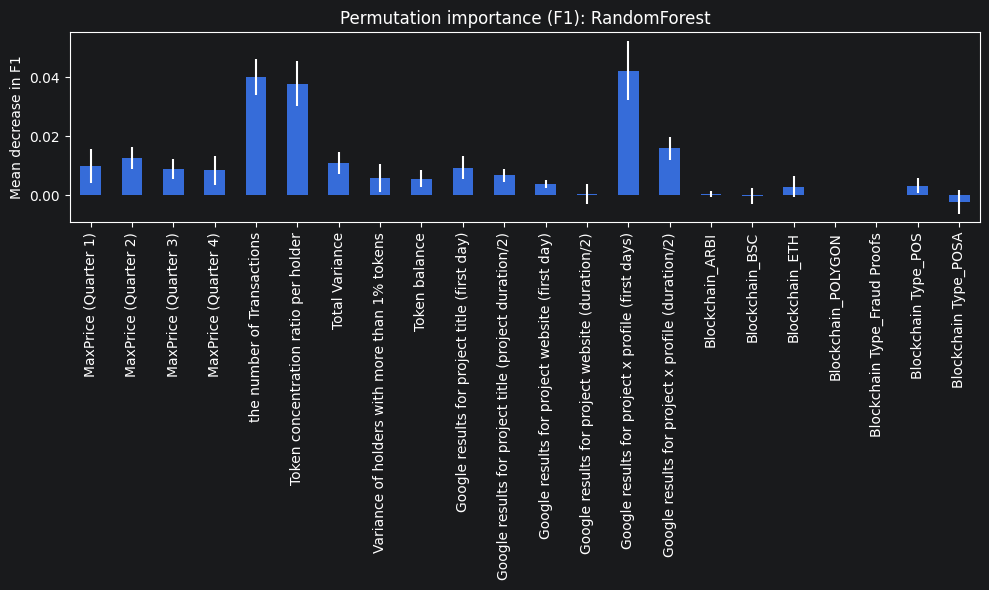

XGBoost
[('Google results for project x profile (first days)', np.float64(0.08968716686029236)), ('the number of Transactions', np.float64(0.07727159685877326)), ('MaxPrice (Quarter 1)', np.float64(0.013817257529220982)), ('MaxPrice (Quarter 2)', np.float64(0.007433078727836806)), ('Blockchain Type_POSA', np.float64(0.006541174576320008)), ('Google results for project x profile (duration/2)', np.float64(0.006490684115397205)), ('Google results for project title (project duration/2)', np.float64(0.005459932988876104)), ('Total Variance', np.float64(0.005014398417719413)), ('Token concentration ratio per holder', np.float64(0.004398686369608118)), ('Google results for project website (duration/2)', np.float64(0.0028452528155406666)), ('Google results for project website (first day)', np.float64(0.0021119904228915744)), ('Token balance', np.float64(0.0020110642858473748)), ('Blockchain_ETH', np.float64(0.001981978357397418)), ('Blockchain_BSC', np.float64(0.001973670897239599)), ('MaxPric

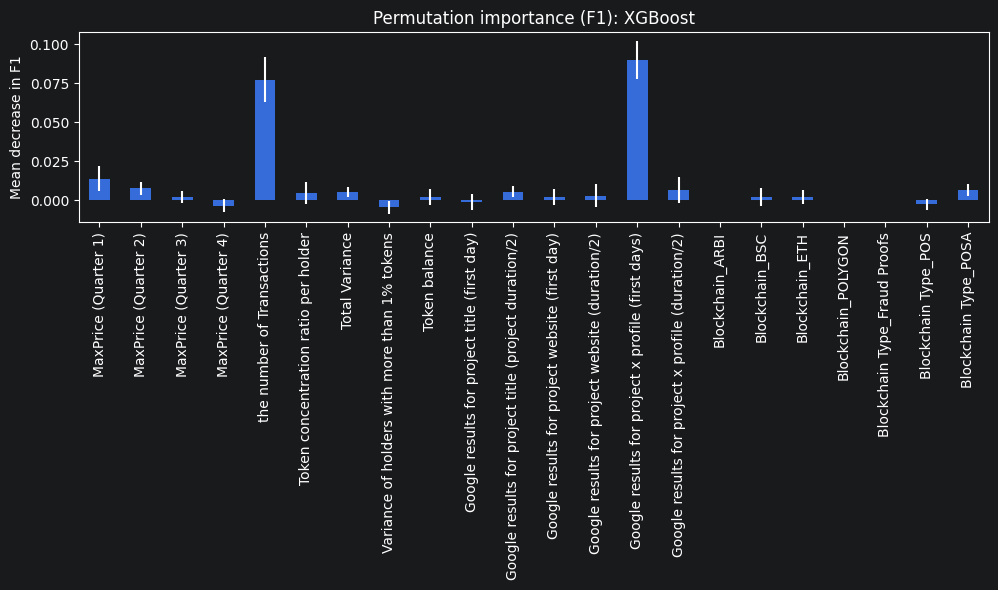

KNeighbors
[('Google results for project x profile (first days)', np.float64(0.036708792067279575)), ('the number of Transactions', np.float64(0.026431590600867628)), ('Token concentration ratio per holder', np.float64(0.02458898184353838)), ('Token balance', np.float64(0.015421265113468308)), ('Variance of holders with more than 1% tokens', np.float64(0.014505977763299116)), ('Google results for project x profile (duration/2)', np.float64(0.013320318054096326)), ('MaxPrice (Quarter 3)', np.float64(0.01138946725836063)), ('Total Variance', np.float64(0.011310002696052878)), ('MaxPrice (Quarter 1)', np.float64(0.010518047113226358)), ('MaxPrice (Quarter 4)', np.float64(0.008865108487606788)), ('MaxPrice (Quarter 2)', np.float64(0.007516460362500732)), ('Google results for project website (duration/2)', np.float64(0.005850642086030045)), ('Google results for project title (project duration/2)', np.float64(0.004616083095817602)), ('Google results for project title (first day)', np.float64

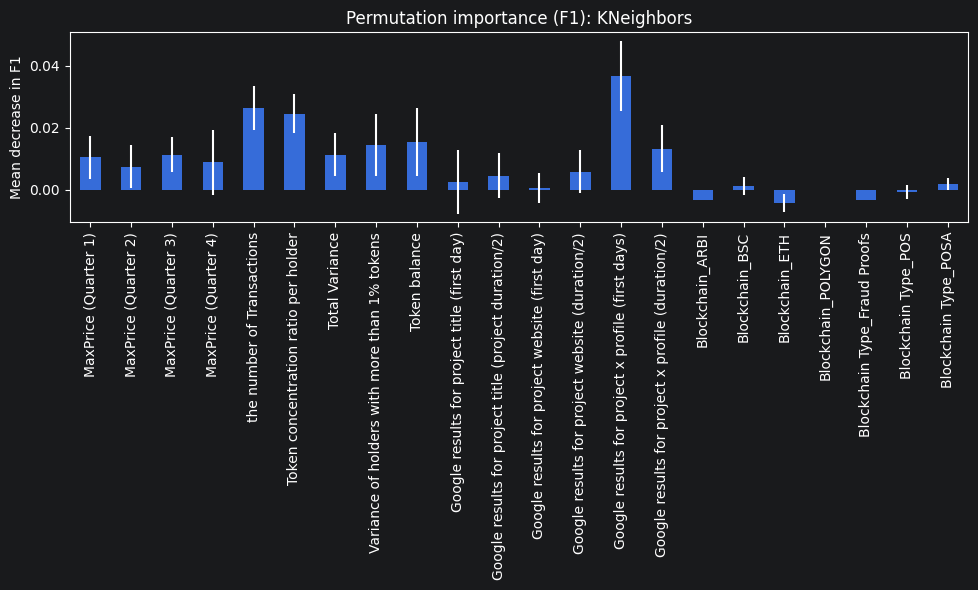

SVC
[('Google results for project x profile (first days)', np.float64(0.03841507908885109)), ('the number of Transactions', np.float64(0.023573206986841167)), ('Token concentration ratio per holder', np.float64(0.01837602562843189)), ('Total Variance', np.float64(0.005861517281179507)), ('MaxPrice (Quarter 2)', np.float64(0.0052232315629485385)), ('MaxPrice (Quarter 1)', np.float64(0.004780024299232788)), ('Google results for project x profile (duration/2)', np.float64(0.004721199779948016)), ('Google results for project title (first day)', np.float64(0.002280881991980155)), ('Blockchain_ARBI', np.float64(0.0017654188703393192)), ('Blockchain Type_Fraud Proofs', np.float64(0.0017654188703393192)), ('Token balance', np.float64(0.001615236785452534)), ('Blockchain_ETH', np.float64(0.0007303825844456769)), ('Blockchain_POLYGON', np.float64(0.0006126973125377466)), ('Blockchain_BSC', np.float64(0.00010969374932483511)), ('Google results for project website (duration/2)', np.float64(-0.0007

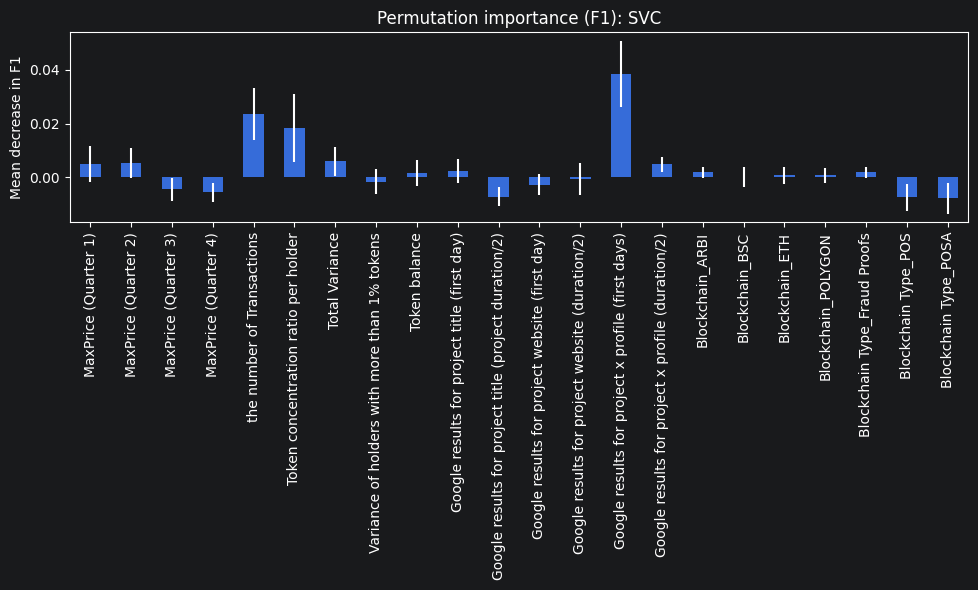

In [17]:
# Assess feature importance with permutation importance and plot the results

# Reference: A. Khan, A. Ali, J. Khan, F. Ullah and M. Faheem, "Using Permutation-Based Feature Importance for Improved Machine Learning Model Performance at Reduced Costs," in IEEE Access, vol. 13, pp. 36421-36435, 2025
# Reference: https://scikit-learn.org/stable/modules/permutation_importance.html

from sklearn.inspection import permutation_importance

def assess_feature_importance_with_permutation(name, model, X, Y, feature_names, n_repeats=10):
    result = permutation_importance(
        model, X, Y,
        scoring="f1",
        n_repeats=n_repeats,
        random_state=seed,
        n_jobs=-1
    )

    scores = dict(zip(feature_names, result.importances_mean))
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    print(name)
    print(sorted_scores)

    importances = pd.Series(result.importances_mean, index=feature_names)
    std = pd.Series(result.importances_std, index=feature_names)

    fig, ax = pyplot.subplots(figsize=(10, 6))
    importances.plot.bar(yerr=std, ax=ax)
    ax.set_title(f"Permutation importance (F1): {name}")
    ax.set_ylabel("Mean decrease in F1")
    fig.tight_layout()
    pyplot.show()

for name, model in models:
    assess_feature_importance_with_permutation(name, model, X_test, Y_test, feature_names)

RandomForest
[('the number of Transactions', np.float64(0.1842560864868961)), ('Token concentration ratio per holder', np.float64(0.1485915496115381)), ('Google results for project x profile (first days)', np.float64(0.12709777925209098)), ('MaxPrice (Quarter 1)', np.float64(0.07398856332883437)), ('MaxPrice (Quarter 2)', np.float64(0.05678653565569994)), ('MaxPrice (Quarter 3)', np.float64(0.05644929316586073)), ('Google results for project x profile (duration/2)', np.float64(0.056191997724268555)), ('MaxPrice (Quarter 4)', np.float64(0.043652118198801625)), ('Total Variance', np.float64(0.040648792759451206)), ('Variance of holders with more than 1% tokens', np.float64(0.03378821495469695)), ('Google results for project title (project duration/2)', np.float64(0.03315358687076262)), ('Token balance', np.float64(0.029039522025166995)), ('Google results for project title (first day)', np.float64(0.028508569425408005)), ('Google results for project website (first day)', np.float64(0.0248

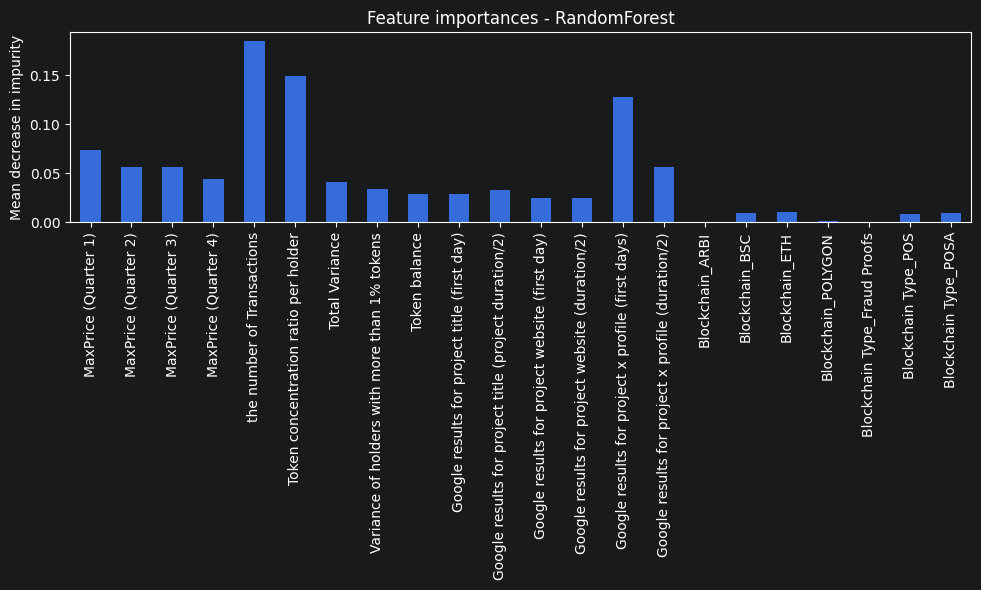

XGBoost
[('the number of Transactions', np.float32(0.25104567)), ('Blockchain_BSC', np.float32(0.113368675)), ('Google results for project x profile (first days)', np.float32(0.06740804)), ('MaxPrice (Quarter 3)', np.float32(0.0652191)), ('Token concentration ratio per holder', np.float32(0.06263142)), ('MaxPrice (Quarter 1)', np.float32(0.054252647)), ('MaxPrice (Quarter 2)', np.float32(0.048889294)), ('Blockchain_ETH', np.float32(0.04637513)), ('Blockchain Type_POS', np.float32(0.044757232)), ('Google results for project website (duration/2)', np.float32(0.035842527)), ('Google results for project title (project duration/2)', np.float32(0.031245839)), ('Google results for project x profile (duration/2)', np.float32(0.030949598)), ('Total Variance', np.float32(0.029921575)), ('Variance of holders with more than 1% tokens', np.float32(0.026292907)), ('Google results for project title (first day)', np.float32(0.020857273)), ('Token balance', np.float32(0.019767275)), ('Google results fo

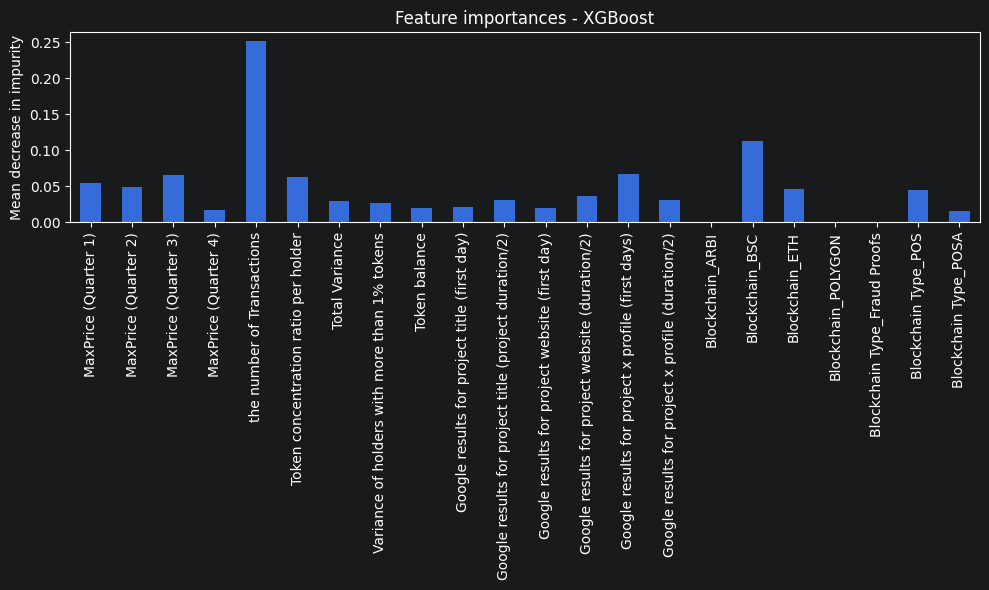

In [18]:
# Assess feature importance for Random Forest and XGBoost with feature_importances_ property and plot them

# Reference: CSM010-2024-APR, Topic 5. 5.12 Hands-on programming demo: evaluating models

def assess_feature_importance_RF_XGBoost_with_plots(name, model, feature_names):
    scores = dict(zip(feature_names, model.feature_importances_))
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    print(name)
    print(sorted_scores)

    importances = pd.Series(model.feature_importances_, index=feature_names)

    fig, ax = pyplot.subplots(figsize=(10, 6))
    importances.plot.bar(ax=ax)
    ax.set_title(f"Feature importances - {name}")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    pyplot.show()

for name, model in models:
    if name in ("RandomForest", "XGBoost"):
        assess_feature_importance_RF_XGBoost_with_plots(name, model, feature_names)

In [19]:
#TODO: describe the whole pipeline


#- load data -> create split -> drop columns -> encode class labels -> transfer data to numeric